<h1 align="center">Medical costs dataset</h1>

<h2 align="center">Introduction</h2>
<p>this dataset is known for having linear relationships on top of wich you can build regressions , thus, this will be my goal in this project, I am going to experiment and hopefully learn how to properly use a regression for predicting an output and later attempt different models as well.<br>

<style>
  ol {
    list-style-type: none;
    counter-reset: item -1;
  }
  ol li {
    display: block;
  }
  ol li:before {
    content: counters(item, ".") " ";
    counter-increment: item;
    font-weight: bold;
  }
  ol ol {
    counter-reset: item 0;
  }
</style>

<ol>
  <li>Dataset importing</li>
  <li>Data Visualisation <ol>
      <li>age graphics
       <ol>
          <li>Histogram of ages </li>
          <li>Histogram of ages by sex</li>
          <li>Histogram of ages by smoker status</li>
          <li>Histogram of ages by region</li>
       </ol>
      </li>
      <li> bmi graphics
        <ol>
          <li>Histogram of bmis </li>
          <li>Histogram of bmi by sex</li>
          <li>Histogram of bmi by smoker status</li>
          <li>Histogram of bmi by region</li>
        </ol>
      </li>
      <li> charges graphics
        <ol>
          <li>Histogram of charges </li>
          <li>Histogram of charges by sex</li>
          <li>Histogram of charges by smoker status</li>
          <li>Histogram of charges by region</li>
        </ol>
      </li>
  </li>
  </ol>
  <li>Relationships between data</li>
    <ol>
        <li> Correlation heatmap </li>
        <li> Scatterplot of bmi and age </li>
        <li> Scatterplot of bmi and southwest </li>
        <li> Scatterplot of charges and bmi </li>
        <li>Age and charges scatterplot</li>
        <li>Charges by age for each location</li>
    </ol>
</ol


<h2 align="center"> Dataset description and importing </h2>
<p> the dataset was found in "Machine Learning with R" by Brett Lantz, it was cleaned up and published on kaggle by Miri Choi (mirichoi0218)<br>
<p> contents :</p>
<ul>
  <li>Age - ages of the beneficiary, integers ranging from 18 to 64 </li>
  <li>Sex - male and female, initially strings </li>
  <li>BMI - body mass index ranging from 15.96 to 53.13</li>
  <li>Children - number of children registered, from 0 to 5</li>
  <li>Smoker Status - initially yes and no strings</li>
  <li>Region - initially southwest, southeast, nothwest, notheast strings</li>
  <li>Charges - individual bills from health insurance, from 1121.87 63770.42
</ul>
<p> these fields will be later be manipulated according to the needs of the project
<p> first modification : changed sex and smoker status to dummy variables in order to incorporate them in my models


In [23]:
from copy import deepcopy
import pandas as pd
import kagglehub
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
path = r"C:\Users\dariu\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1\insurance.csv"
df = pd.read_csv(path)


path = kagglehub.dataset_download("mirichoi0218/insurance")
df = pd.read_csv(f"{path}/insurance.csv")
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})


# uncomment this if you are running from another device
# path = kagglehub.dataset_download("mirichoi0218/insurance")
# csv_path = os.path.join(path, "insurance.csv")
# df = pd.read_csv(csv_path)
# print(df.head())


#this will be used
auxdf = deepcopy(df)

<h2 align="center">1.1 Age graphics</h2>
<p style="text-align: center;"> below you will find multiple graphics describing ages and it s relationships with data </p>

<h4 align="center">1.1.1 Ages histogram</h4>
<p> the average age is 39 overall, as you can see, the number of 20 years olds is much greater than any other age <br>
<p> the standard deviation is $\sigma = 14 $ resulting in a  $-1\sigma$ and $+1\sigma$ range of 28.08 ranging from 25 to 53

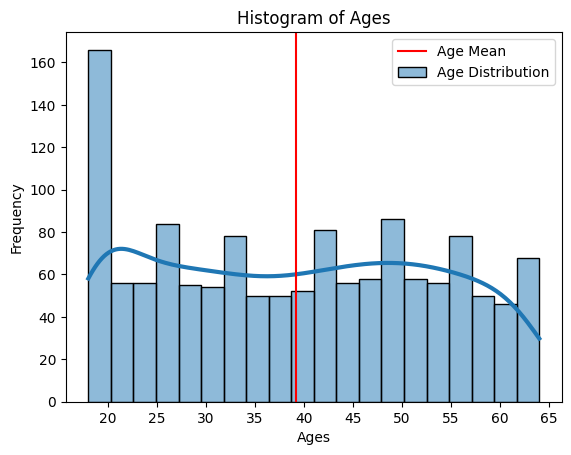

In [24]:
ageMean= df["age"].mean()
ageDeviation = df["age"].std()
x= ageMean - ageDeviation
y =ageMean + ageDeviation

plt.figure()
plt.grid(False)
sns.histplot(data=df, x="age", bins=20, edgecolor="black", kde=True,line_kws={"color": "purple", "linewidth": 3},label="Age Distribution")
plt.xticks(range(20,66,5))
plt.xlabel("Ages")
plt.ylabel("Frequency")
plt.axvline(x=ageMean, color="red",label="Age Mean")
plt.legend()
plt.title("Histogram of Ages")
plt.show()

<h4 align="center">1.1.2 Ages histogram by sex </h4>
<p> as you can see below, the difference between male and female ages are similar, having roughly the same amount of data for both cathegories

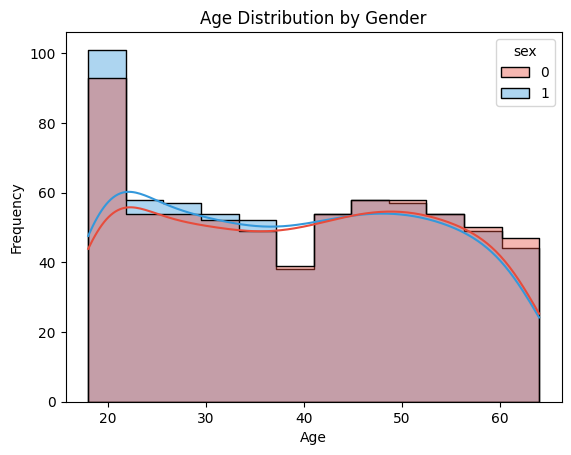

In [25]:
plt.figure()
plt.grid(False)
sns.histplot(data=df, x="age", hue="sex",edgecolor = "black", kde=True, palette={1: "#3498db", 0: "#e74c3c"}, alpha=0.4, element="step")
plt.xlabel("Ages")
plt.ylabel("Frequency")
plt.title("Age Distribution by Gender")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

<h4 align="center">1.1.3 Ages of smokers vs non smokers </h4>
<p>

<Figure size 640x480 with 0 Axes>

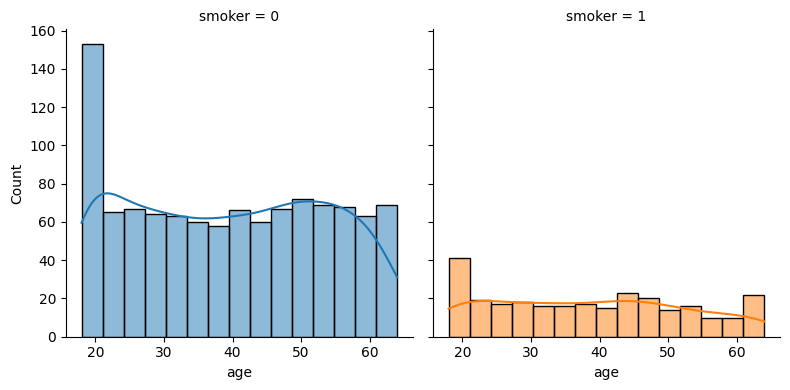

In [26]:
plt.figure()
g = sns.FacetGrid(df, col="smoker", hue="smoker", height=4, aspect=1)
g.map(sns.histplot, "age", kde=True,bins=15)

<h4 align="center">1.1.4 Ages of people from different regions </h4>
<p>

<Figure size 640x480 with 0 Axes>

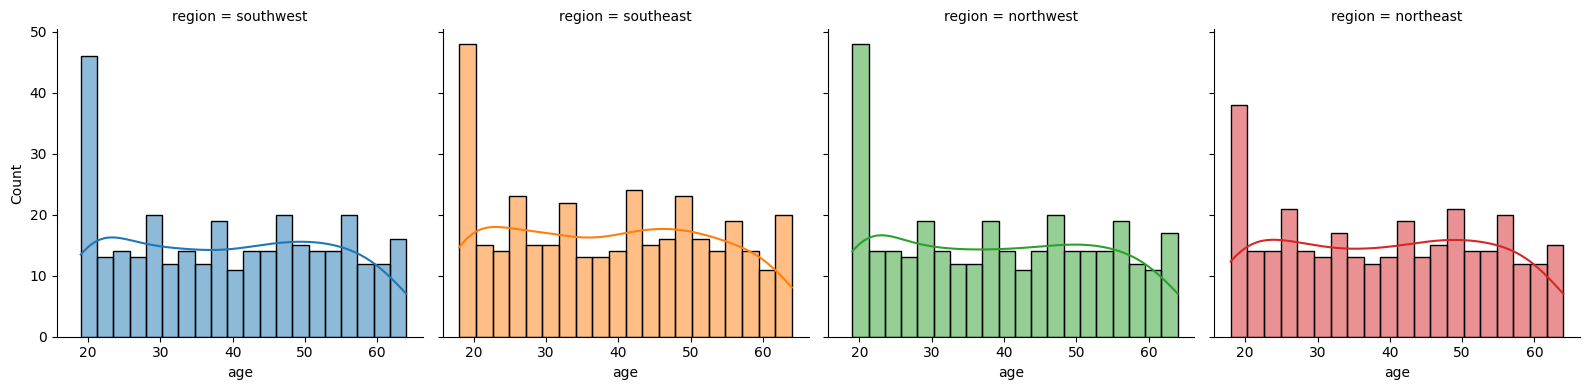

In [27]:
plt.figure()
g = sns.FacetGrid(df, col="region", hue="region", height=4, aspect=1)
g.map(sns.histplot, "age", kde=True,bins = 20)
# meanSW = df.loc[df['region'] == 'southwest', 'age'].mean()
# print(meanSW)

<h2 align="center">1.2 BMI graphics </h2>

<h4 align="center">1.2.1 histogram of BMI s </h4>

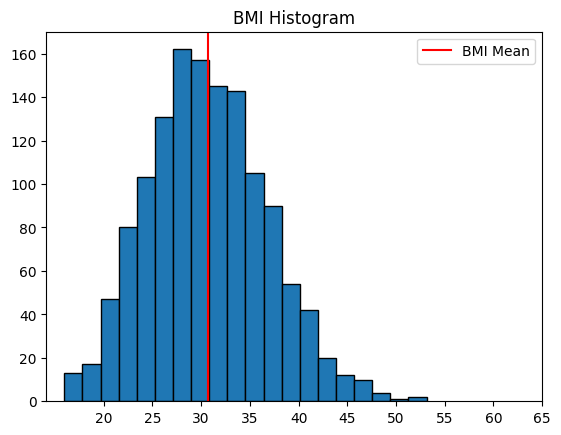

In [28]:
plt.figure()
plt.grid(False)
bmiMean= df["bmi"].mean()
plt.hist(df["bmi"],bins = 20,edgecolor="black")
plt.xticks(range(20,66,5))
plt.title("BMI Histogram")
plt.axvline(x=bmiMean, color="red",label="BMI Mean")
plt.legend()

<h4 align="center">1.2.2 Histogram of bmi by sex</h4>

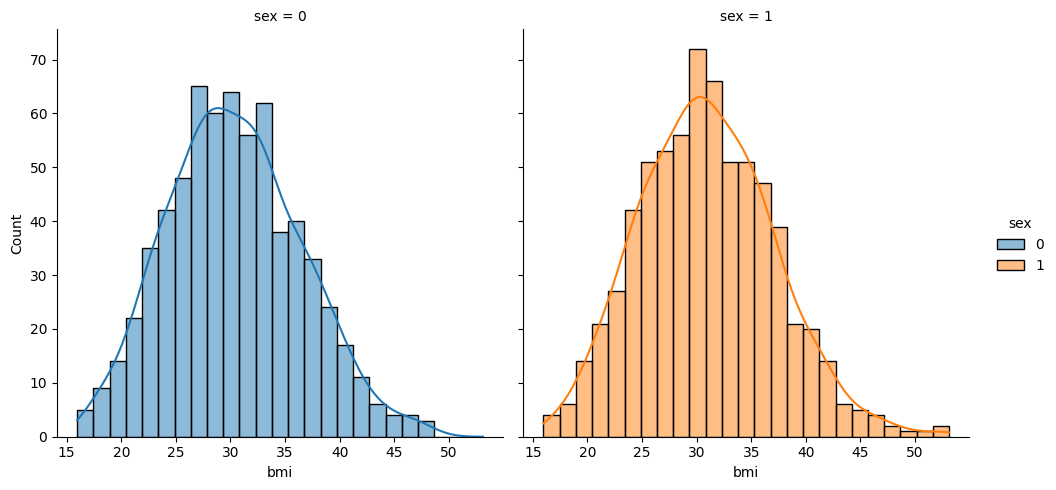

In [29]:
g = sns.displot(data = df, x = "bmi", col = "sex",hue ="sex", kind= "hist", kde = True, aspect=1)

<h4 align="center">1.2.3 Histogram of bmi by smoker status</h4>

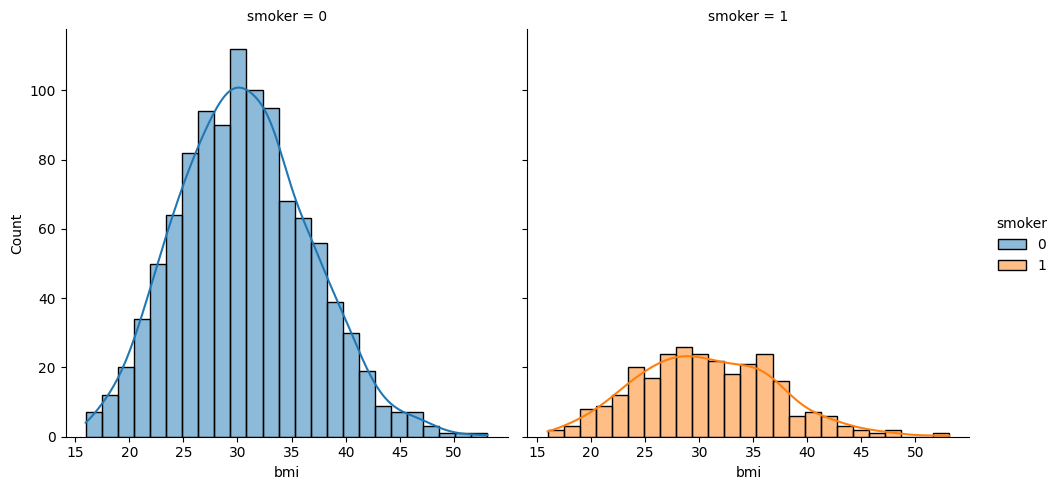

In [30]:
g = sns.displot(data = df, x = "bmi", col = "smoker",hue ="smoker", kind= "hist", kde = True, aspect=1)

<h4 align="center">1.2.4 Histogram of bmi by charges</h4>

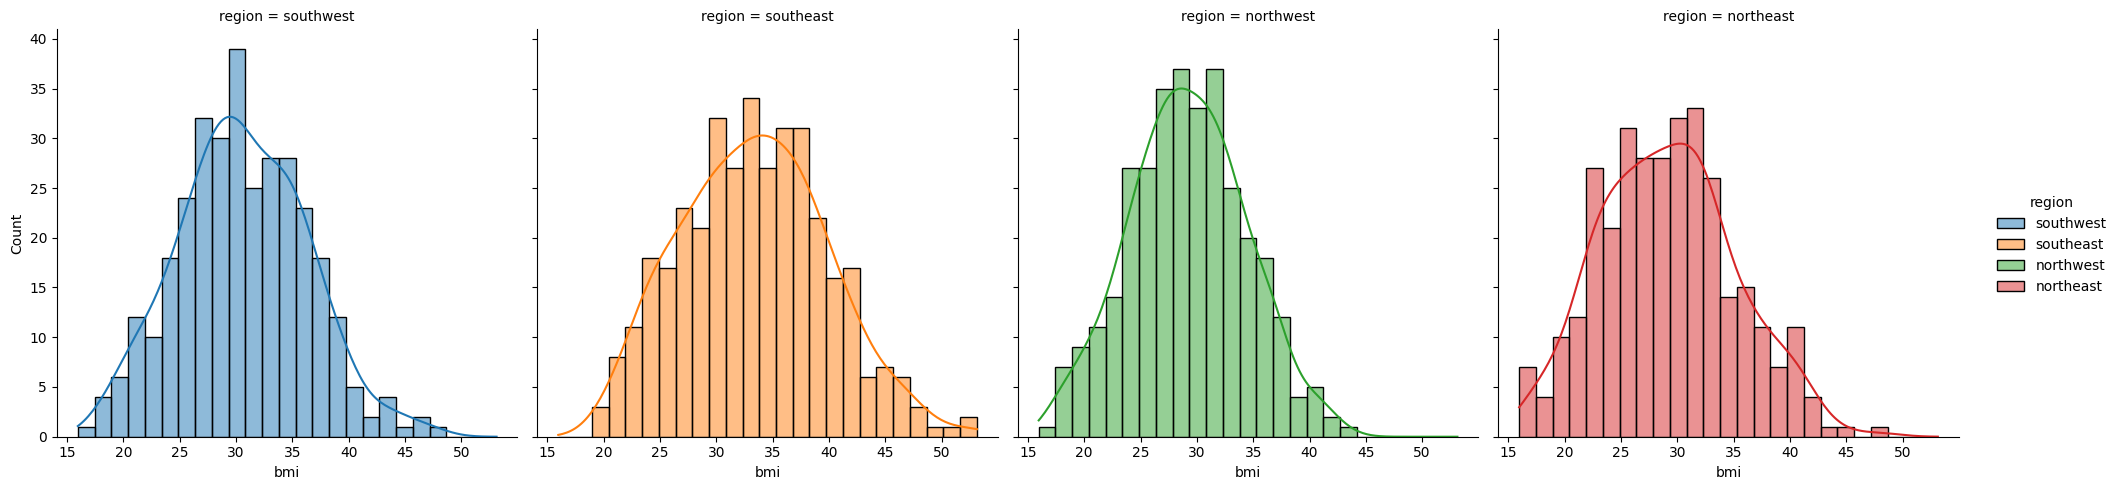

In [31]:
# g = sns.FacetGrid(df, col="region", aspect=1)
# g.map(sns.histplot, "bmi", kde=True)
# g.set(xticks= range(20,66,5))
g = sns.displot(data = df,x="bmi",col="region",hue="region",kind="hist",kde=True,aspect=1)
plt.show()


<h2 align="center">1.3 charges graphics</h2>

<h4 align = "center">1.3.1 Histogram of charges </h4>

Text(0.5, 1.0, 'Histogram of Charges')

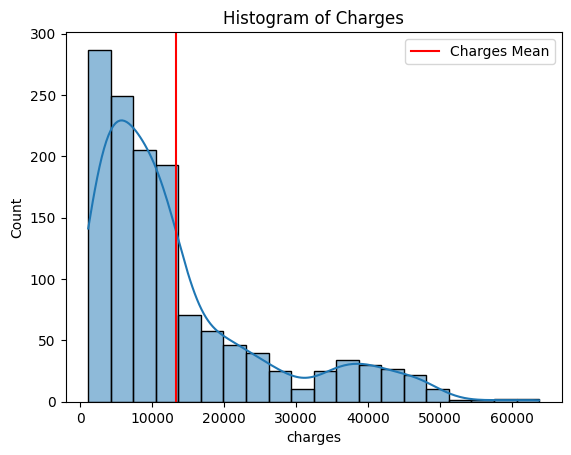

In [32]:
plt.figure()
plt.grid(False)
sns.histplot(data = df, x = "charges", bins = 20, edgecolor = "black", kde = True)
chargeMean = np.mean(df["charges"])
plt.axvline(x=chargeMean, color="red",label="Charges Mean")
plt.legend()
plt.title("Histogram of Charges")

<h4 align = "center">1.3.2 Histogram of charges by sex </h4>

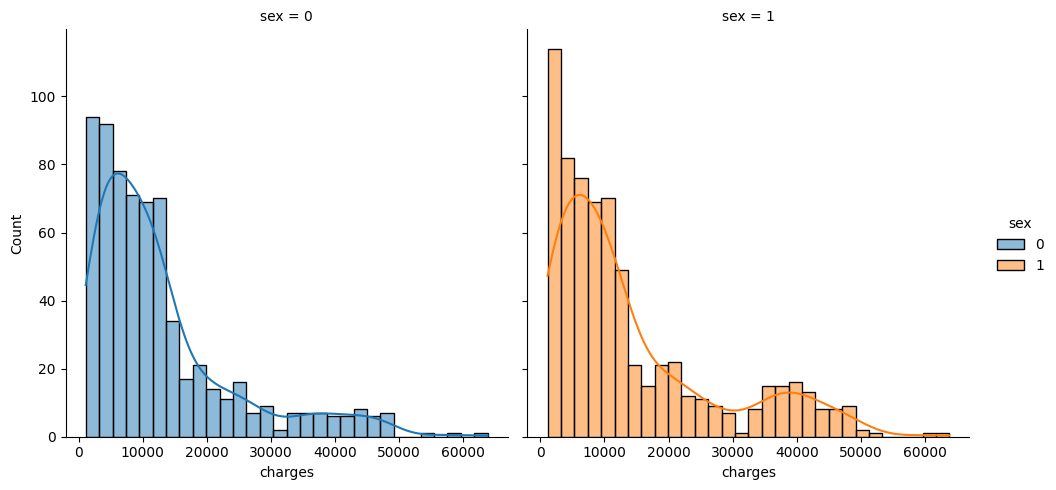

In [33]:
g= sns.displot(data = df, x = "charges",col = "sex", hue="sex", kind="hist", kde=True, aspect=1)

<h4 align = "center">1.3.3 Histogram of charges by smoker status </h4>

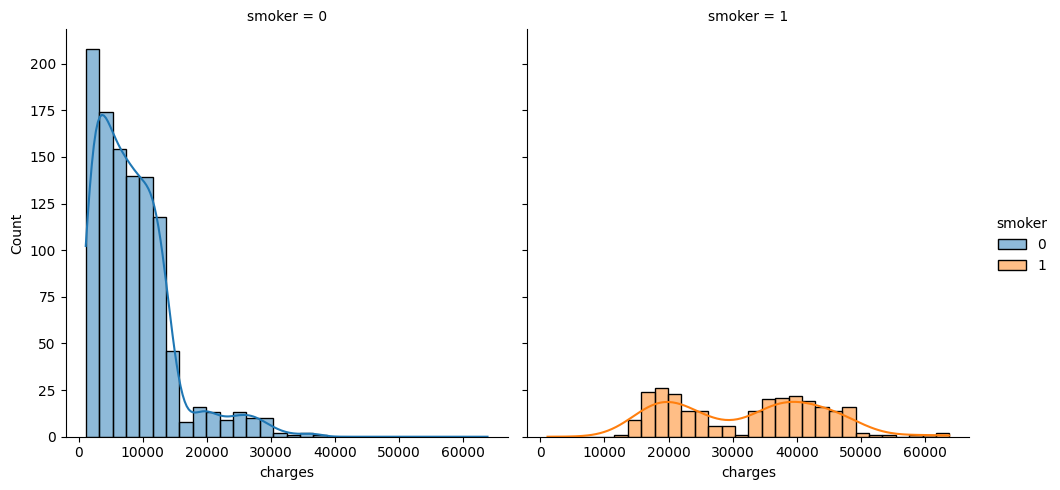

In [34]:
g= sns.displot(data = df, x = "charges",col = "smoker", hue="smoker", kind="hist", kde=True, aspect=1)

<h4 align = "center">1.3.4 Histogram of charges by region </h4>

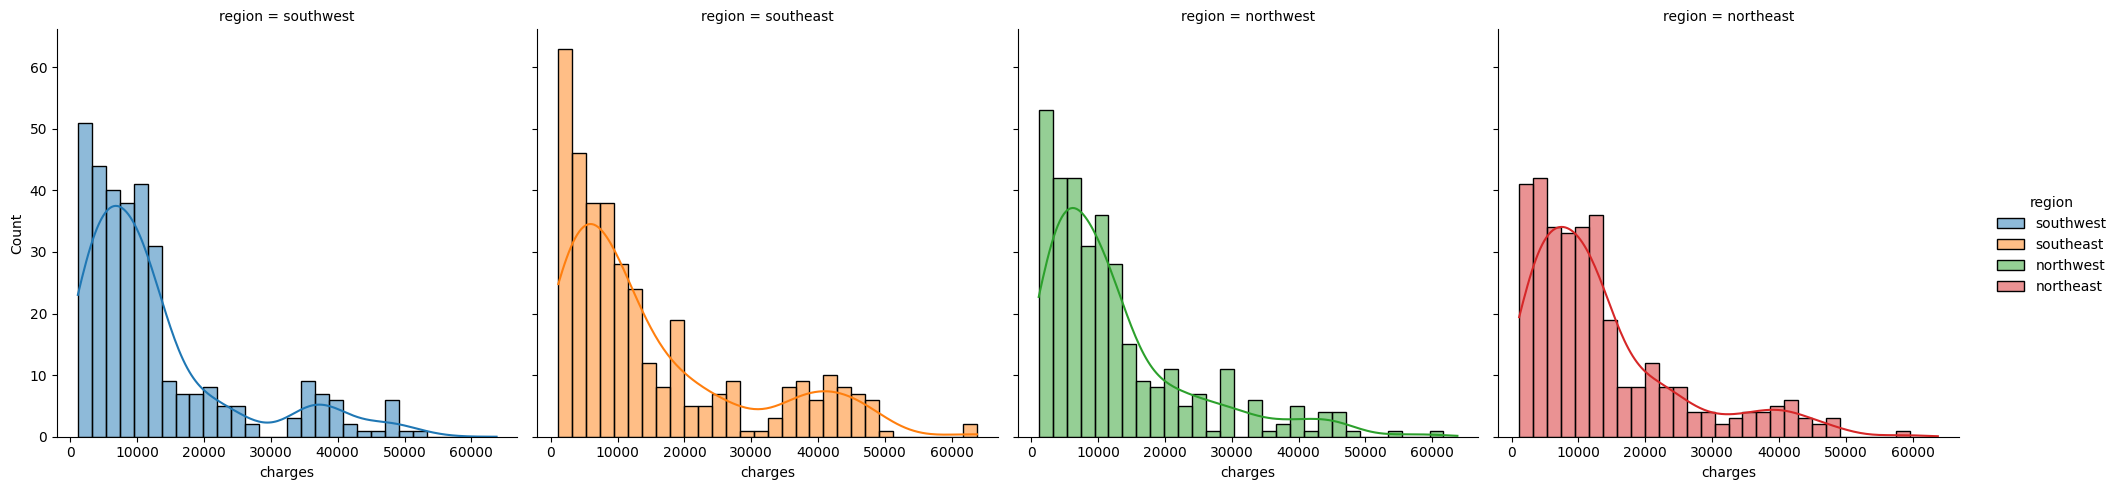

In [35]:
g = sns.displot(data = df, x="charges",col="region", hue="region", kind="hist", kde=True, aspect=1)

<h2 align = "center"> 2 Relationships between data </h2>
<p> this section is dedicated to the visualisations of the datapoints, how datapoints are scattered, what data has meaningful correlations etc

<h4 align = "center"> 2.1 Correlation heatmap </h4>
here we will get the R value of each intersection using Pearson s correlation

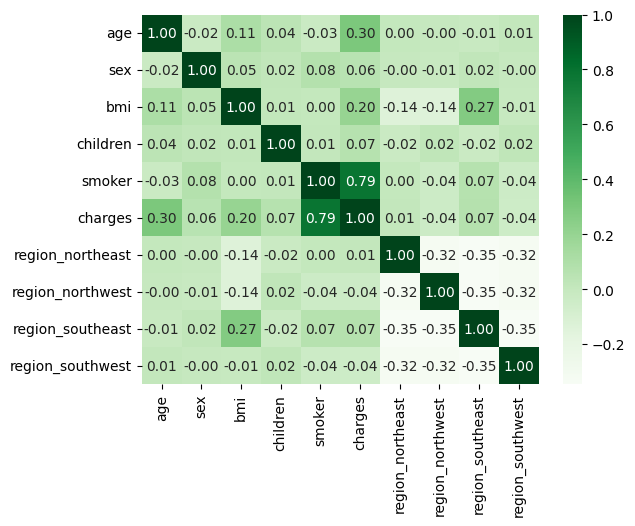

In [36]:
df = pd.get_dummies(df, columns=['region'], prefix='region')
corr= df.corr()
sns.heatmap(corr, annot=True,fmt=".2f", cmap="Greens")
#small trick to revert the df to it s original form for further operations *wink*
df = deepcopy(auxdf)


<h4 align = "center"> 2.2 Scatterplot of bmi and age</h4>
<p> shows the different points between age and bmi, we observe a very large amount of uneven residual spread, making my prediction interval very wide, despite seeming homoscedastic the data has very little value due to a very low R2.
Despite having a linear relationship, the value of the relationship is almost neglectable due to big residuals

The correlation coefficient (r) is: 0.109
The r squared is: 0.012


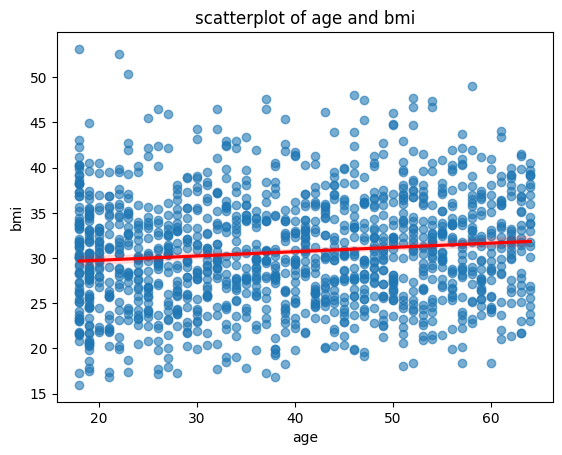

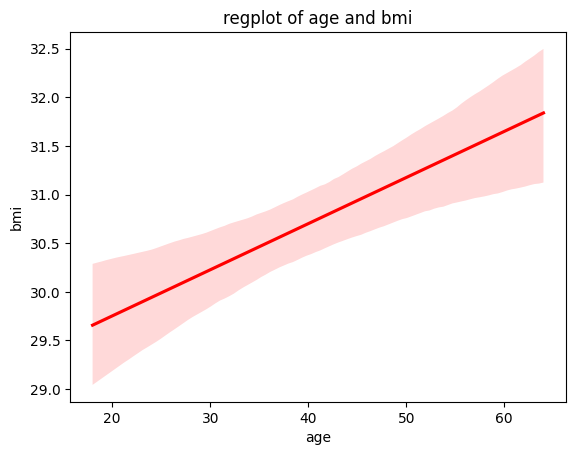

In [37]:
plt.figure()
sns.regplot(data=df, x="age", y="bmi", scatter_kws={'alpha':0.6},line_kws={"color": "red"})
plt.title("scatterplot of age and bmi")
plt.figure()
sns.regplot(data=df, x="age", y="bmi", scatter = False,line_kws={"color": "red"})
plt.title("regplot of age and bmi")
corr_val = df["age"].corr(df["bmi"])
print(f"The correlation coefficient (r) is: {corr_val:.3f}")
r_square = corr_val**2
print(f"The r squared is: {r_square:.3f}")

<h4 align = "center"> 2.3 Scatterplot of bmi and southwest</h4>
<p> this graph will just show you there is a difference between the means of the southeasteners and the other people in the dataset

The correlation coefficient (r) is: 0.109
The R squared is: 0.012


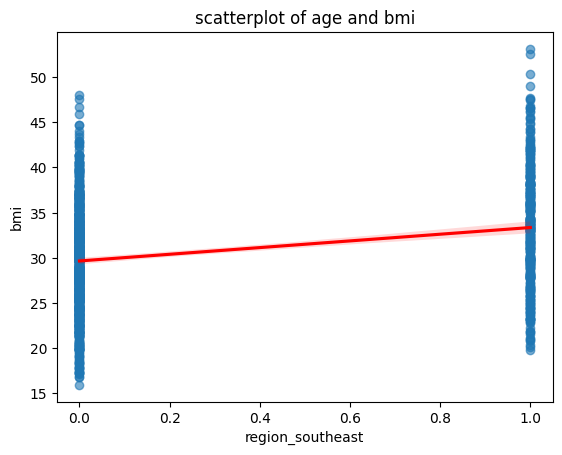

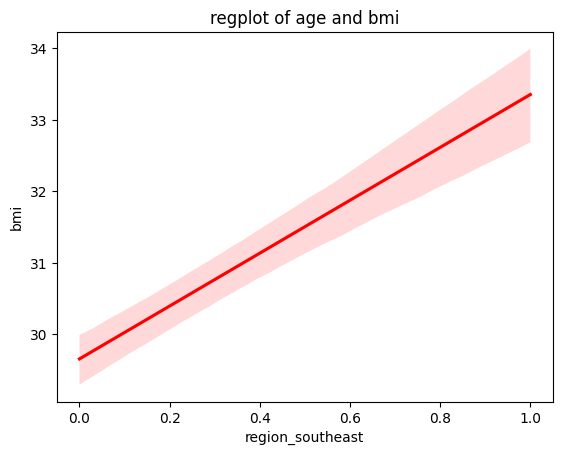

In [38]:
df = pd.get_dummies(df, columns=['region'], prefix='region')
plt.figure()
sns.regplot(data=df, x="region_southeast", y="bmi", scatter_kws={'alpha': 0.6}, line_kws={"color": "red"})
plt.title("scatterplot of age and bmi")
plt.figure()
sns.regplot(data=df, x="region_southeast", y="bmi", scatter=False, line_kws={"color": "red"})
plt.title("regplot of age and bmi")
corr_val = df["age"].corr(df["bmi"])
R2 = corr_val**2
print(f"The correlation coefficient (r) is: {corr_val:.3f}")
print(f"The R squared is: {R2:.3f}")
df = deepcopy(auxdf)

<h4 align = "center"> 2.4 scatterplot of charges and bmi</h4>
<p> so, as you can see below, the R2 of non smokers bmis is 0.007, we can safely assume that the charges of a non smoker are not caused by bmi increase</p>
<p> the smoker situation on the other hand is much different, having an r2 of 0.65 compared to the non smokers of below 0.01, bmis seem to have a much bigger impact on charges for smokers, it is likely that charges are influenced by bmi

The correlation coefficient between smokers bmis and charges(r) is: 0.806
The R squared is: 0.650
The correlation coefficient between non smokers bmis and charges(r) is: 0.084
The R squared is: 0.007


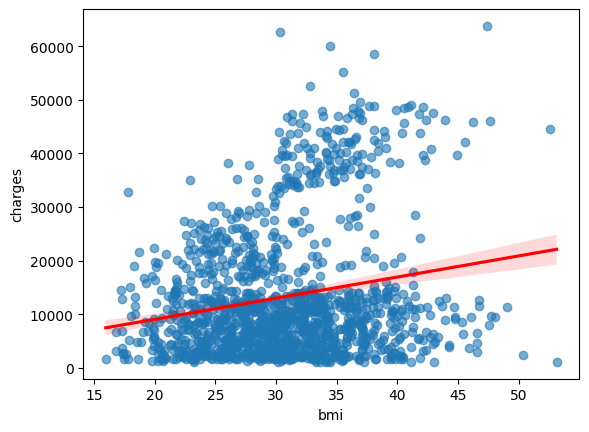

<Figure size 640x480 with 0 Axes>

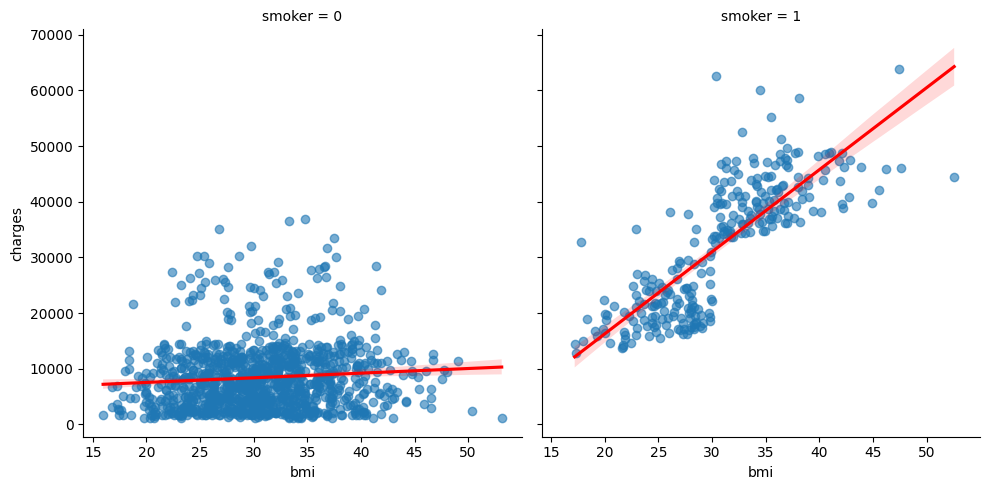

In [39]:
plt.figure()
sns.regplot(data=df, x="bmi", y="charges", scatter_kws={'alpha': 0.6}, line_kws={"color": "red"})

plt.figure()
sns.lmplot(data=df, x="bmi", y="charges",col="smoker", scatter_kws={'alpha': 0.6}, line_kws={"color": "red"})

smoker = df[df["smoker"] == 1]
corr_val = smoker["bmi"].corr(smoker["charges"])
r2 = corr_val ** 2
nonsmoker = df[df["smoker"] == 0]
corr_val2 = nonsmoker["bmi"].corr(nonsmoker["charges"])
r22 = corr_val2 ** 2
print(f"The correlation coefficient between smokers bmis and charges(r) is: {corr_val:.3f}")
print(f"The R squared is: {r2:.3f}")
print(f"The correlation coefficient between non smokers bmis and charges(r) is: {corr_val2:.3f}")
print(f"The R squared is: {r22:.3f}")


<h4 align = "center" > 2.5 Age and charges scatterplot </h4>
<p> as we can see aging for smokers is not the main cause of charge increments, since the R2 of smoker charges by age is quite small having 0.13
<p> on the other hand, age does a much better job at explaining why non smokers charges increase even with varying bmis

<Figure size 640x480 with 0 Axes>

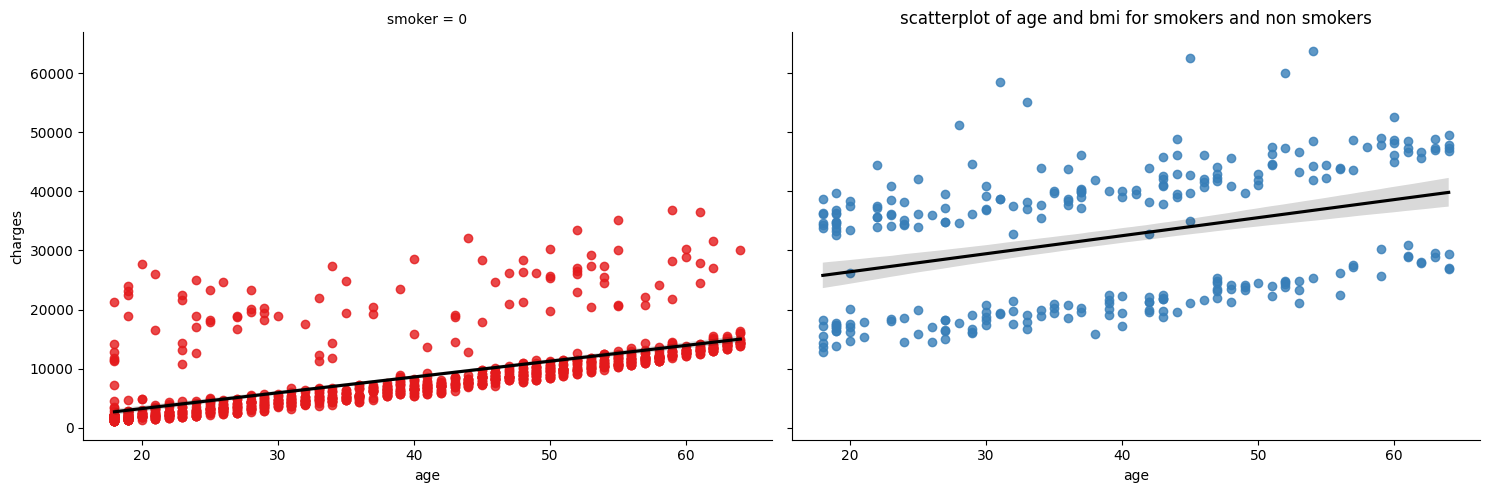

The correlation coefficient between smokers ages and charges(r) is: 0.368
The R squared is: 0.136
The correlation coefficient between non smokers ages and charges(r) is: 0.628
The R squared is: 0.394


In [40]:
plt.figure()
sns.lmplot(data=df, x="age", y="charges", hue="smoker", col="smoker", palette="Set1", aspect=1.5,
           line_kws={"color": "black"})
plt.title("scatterplot of age and bmi for smokers and non smokers")
plt.show()

smoker = df[df["smoker"] == 1]
corr_val = smoker["age"].corr(smoker["charges"])
r2 = corr_val ** 2
nonsmoker = df[df["smoker"] == 0]
corr_val2 = nonsmoker["age"].corr(nonsmoker["charges"])
r22 = corr_val2 ** 2
print(f"The correlation coefficient between smokers ages and charges(r) is: {corr_val:.3f}")
print(f"The R squared is: {r2:.3f}")
print(f"The correlation coefficient between non smokers ages and charges(r) is: {corr_val2:.3f}")
print(f"The R squared is: {r22:.3f}")

<h4 align = "center"> 2.6 Charges by age for each location </h4>
<p> we can see each of the 4 region has an R2 ranging from 0.06 to 0.11, whilst not the best values I will still try to incorporate them into predictions </p>

      age  sex     bmi  children  smoker     region      charges
0      19    0  27.900         0       1  southwest  16884.92400
1      18    1  33.770         1       0  southeast   1725.55230
2      28    1  33.000         3       0  southeast   4449.46200
3      33    1  22.705         0       0  northwest  21984.47061
4      32    1  28.880         0       0  northwest   3866.85520
...   ...  ...     ...       ...     ...        ...          ...
1333   50    1  30.970         3       0  northwest  10600.54830
1334   18    0  31.920         0       0  northeast   2205.98080
1335   18    0  36.850         0       0  southeast   1629.83350
1336   21    0  25.800         0       0  southwest   2007.94500
1337   61    0  29.070         0       1  northwest  29141.36030

[1338 rows x 7 columns]
0.25835787760143436 0.06674879291871774
0.31059315928465775 0.09646811059442478
0.3376538424947998 0.11401011735150307
0.3009512000834591 0.09057162483167423


<Figure size 640x480 with 0 Axes>

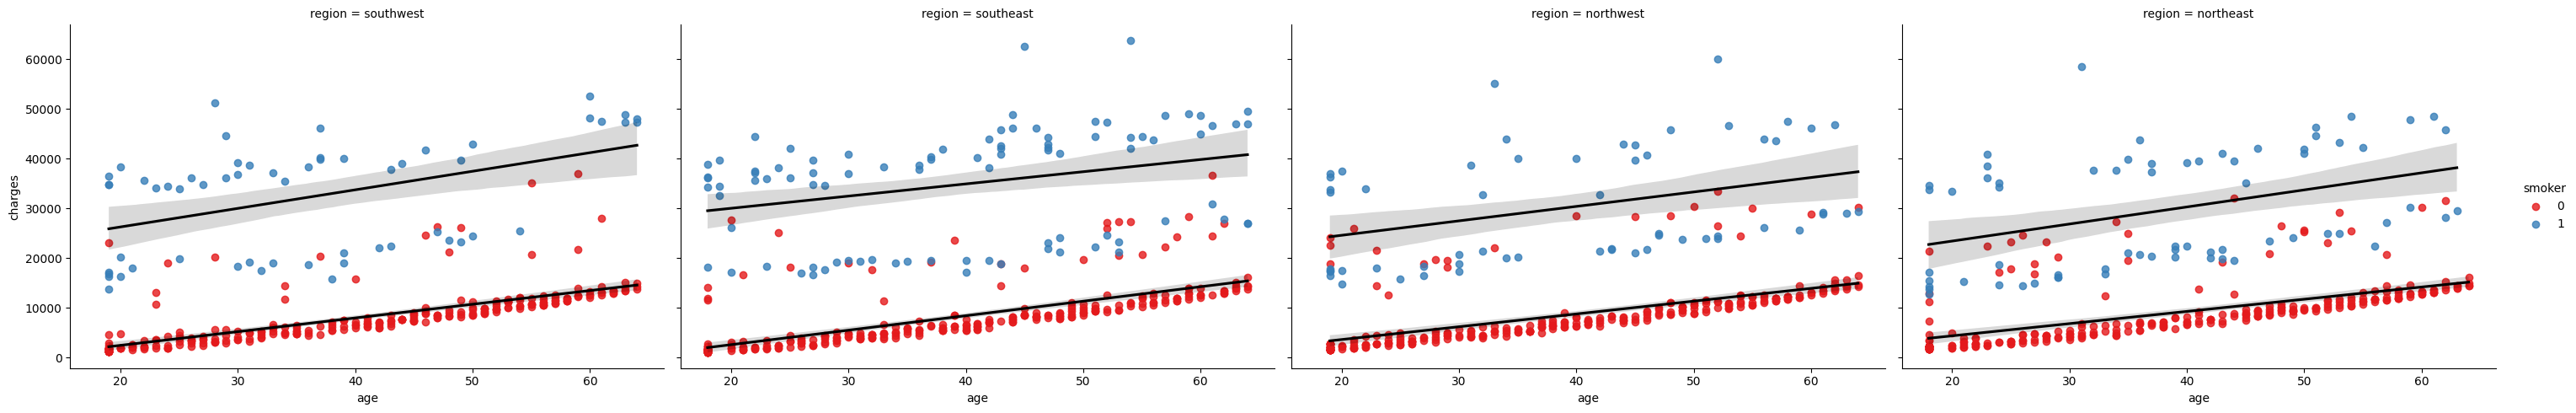

In [41]:
print(df)
plt.figure()
sns.lmplot(data = df, x = "age", y = "charges", hue = "smoker", col = "region", palette="Set1", aspect=1.5,line_kws={"color": "black"})

df = pd.get_dummies(df, columns=['region'], prefix='region')

sw = df[df["region_southwest"] == True]
corr_valsw = sw["age"].corr(sw["charges"])
r2sw = corr_valsw ** 2
print(corr_valsw,r2sw)

se = df[df["region_southeast"] == True]
corr_val = se["age"].corr(se["charges"])
r2 = corr_val ** 2
print(corr_val,r2)

nw = df[df["region_northwest"] == True]
corr_valnw = nw["age"].corr(nw["charges"])
r2nw = corr_valnw ** 2
print(corr_valnw,r2nw)

ne = df[df["region_northeast"] == True]
corr_valne = ne["age"].corr(ne["charges"])
r2ne = corr_valne ** 2
print(corr_valne,r2ne)
df = deepcopy(auxdf)


<h4 align = "center"> 3.1 train test simple model tournament </h4>
<p>
here we will create a tournament of predictive models, but, this being the simplest one, none will be tuned, the models will run on all the parameters, even with the risk of having entropy skew results. I will also not account for information gain at this step, .
<br>
Given the fact that this is my "baseline", I will compare future results to it by refferring to it as 3.1 or "baseline tournament"
</p>
<p> this will test the algorithms in an old school train test split of 70-30, and this results must be taken with a grain of salt since they can be a lucky guess </p>
<p> note that every model with close to .1 variance will be considered overfitted to the training set, also, high bias will also be treated as an issue. </p>

In [42]:
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, RidgeCV,LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor                    
from lightgbm import LGBMRegressor
from sklearn import metrics

df = pd.get_dummies(df, columns=['region'], prefix='region',drop_first=True)

X = df.drop(['charges'], axis=1)
y = df['charges']

x_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "ElasticNet": ElasticNet(),

    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Extra Trees": ExtraTreesRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "XGBoost": XGBRegressor(),
}


print(f"{'Model':<25} | {'Train R2':<10} | {'Test R2':<10} | {'Variance':<10} |  {"bias":<10}| {'MAE':<10}")
print("-" * 100)

for name, model in models.items():
    model.fit(x_train, Y_train)
    predictions = model.predict(X_test)

    train_r2 = model.score(x_train, Y_train)
    r2 = model.score(X_test, Y_test)

    bias = 1 - train_r2
    variance =  train_r2 - r2
    mae = metrics.mean_absolute_error(Y_test, predictions)

    print(f"{name:<20}   | {train_r2:.4f}   |   {r2:.4f}   |  {variance:.4f}    |   {bias:.2f}   |   ${mae:.2f}")

df = deepcopy(auxdf)


Model                     | Train R2   | Test R2    | Variance   |  bias      | MAE       
----------------------------------------------------------------------------------------------------
Linear Regression      | 0.7424   |   0.7696   |  -0.0272    |   0.26   |   $4145.45
Lasso                  | 0.7424   |   0.7696   |  -0.0272    |   0.26   |   $4145.98
Ridge                  | 0.7424   |   0.7694   |  -0.0270    |   0.26   |   $4158.79
ElasticNet             | 0.3871   |   0.4041   |  -0.0170    |   0.61   |   $7332.13
Decision Tree          | 1.0000   |   0.7127   |  0.2873    |   0.00   |   $2862.09
Random Forest          | 0.9760   |   0.8530   |  0.1230    |   0.02   |   $2632.20
Extra Trees            | 1.0000   |   0.8344   |  0.1656    |   0.00   |   $2534.71
Gradient Boosting      | 0.9040   |   0.8658   |  0.0383    |   0.10   |   $2489.77
AdaBoost               | 0.8339   |   0.8217   |  0.0121    |   0.17   |   $4215.73
XGBoost                | 0.9966   |   0.8334   |

as you can see the results are horrible overall<br> starting from the top down, let s see what we can extrapolate from these results  <br>
1 linear regression - the accuracy obtained is decent, not flattering, what is interesting is the negative variance, wich simply tells us the model had a better fit on the test data than the train data, the fact that variance is so small indicates we are not overfitting. Taking a look at variance we might actually say the model is undefit, having a very high bias means it does not efficiently
<br>
2 for ridge regression, we have an issue, since variance and bias stays the same, we are basically using a line very similar to the linear one, to the point that it does not really matter.
The cause of this effect is the very small penalty applied, here labda is 1 wich is apparently too small
<br>
3 Lasso, being very similar to ridge, performed almost the same as ridge, their only difference is the way they handle the slope and the fact that lasso can eliminate non contributing feautures. That being said, the likelihood that my dataset has no useless attributes is quite high, the fact that ridge and lasso are so similar point towards that too, it also tells us the dataset has low noise.
<br><b>note that regularization (lasso ridge and elastic net) works way better with a lot of attributes (50+ for example) because some will likely be useless and it is also better at handling outliers.</b><br>
4 elastic net is also a regularization one, but it is a combination of both ridge and lasso, the funny thing is that combinging the 2 with the standard 1 lambda make the model so strict it will have a horrible output, due to it s strictness it heavily underfitted <br>
NOTE! using elastic net was actually just an experiment for fun, I will refrain from using it in future tests because it would be like using a bazooka to drill a hole for a nail,<br>
5 decision tree, as we can see, it has a 1.00 accuracy, that means each leaf reppesents one entry in the dataset, the tree split itself enough times to fit every single datapoint, now, the variance is 0.16. this is a textbook example of overfit <br>
6 random forests create many trees using bagged data, basically it splits your data in samples and creates trees on said bootstrapped data hence why it performed much better than the decision tree regressor <br>
7 extra tree is basically a random forest where the split is random, unlike random forest where the split is a calculated best, similarly to the decision tree it isolated each entry into a leaf hence it s showing a 1.00 accuracy, variance still very high. <br>
8 gradient boosting default is n_estimatiors = 100 max_depth is 3, and it worked well but can still be tuned <br>
9 hist gradient boosting is similar
10 adaBoost works with depth 1 trees, adaptive boosting works with weights, it looks at the stumps that go wrong and adds weights to those. weights basically tell the model to focus on what s harder to predict, wich leads it to explore outliers <br>
11 xgboost failed because of the same reasons as the others, way too big depth (max_depth is 6 implicitly), it learned the noise.



<h4 align = "center">3.2 k-fold simple model tournament</h4>

In [43]:

df = pd.get_dummies(df, columns=['region'], prefix='region', drop_first=True)

X = df.drop(['charges'], axis=1, errors='ignore')
y = df['charges']


models = {
    "Linear Regression": LinearRegression(),
    "Lasso tuned": Lasso(),
    "Ridge": Ridge(),

    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Extra Trees": ExtraTreesRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "XGBoost": XGBRegressor(),
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)

print(f"{'Model':<25} | {'Train R2':<10} | {'Test R2':<10} | {'Variance':<10} | {'Bias':<10} | {'MAE':<10}")
print("-" * 105)

resultsDictionary = {}

for name, model in models.items():

    resultsDictionary[name] = {
        'train_r2': [], 'test_r2': [], 'mae': [], 'variance': [], 'bias': [], "mse":[], "rmse":[]
    }

    for train_index, test_index in kf.split(X):
        x_train, x_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(x_train, y_train)
        predictions = model.predict(x_test)

        train_r2 = model.score(x_train, y_train)
        test_r2 = model.score(x_test, y_test)

        resultsDictionary[name]['train_r2'].append(train_r2)
        resultsDictionary[name]['test_r2'].append(test_r2)
        resultsDictionary[name]['variance'].append(train_r2 - test_r2)
        resultsDictionary[name]['bias'].append(1 - train_r2)
        resultsDictionary[name]['mae'].append(metrics.mean_absolute_error(y_test, predictions))
        resultsDictionary[name]['mse'].append(metrics.mean_squared_error(y_test, predictions))
        resultsDictionary[name]['rmse'].append(metrics.root_mean_squared_error (y_test, predictions))

    print(f"{name:<25} | "
          f"{np.mean(resultsDictionary[name]['train_r2']):.4f}   | "
          f"{np.mean(resultsDictionary[name]['test_r2']):.4f}      | "
          f"{np.mean(resultsDictionary[name]['variance']):.4f}        | "
          f"{np.mean(resultsDictionary[name]['bias']):.2f}            | "
          f"{np.mean(resultsDictionary[name]['mae']):.2f}              |"
          f"{np.mean(resultsDictionary[name]['mse']):.2f}          |"
          f"{np.mean(resultsDictionary[name]['rmse']):.2f}        |"
)


df = deepcopy(auxdf)

Model                     | Train R2   | Test R2    | Variance   | Bias       | MAE       
---------------------------------------------------------------------------------------------------------
Linear Regression         | 0.7510   | 0.7390      | 0.0120        | 0.25            | 4204.64              |37020264.84          |6070.35        |
Lasso tuned               | 0.7510   | 0.7391      | 0.0120        | 0.25            | 4204.94              |37019189.12          |6070.27        |
Ridge                     | 0.7510   | 0.7391      | 0.0119        | 0.25            | 4213.28              |37019189.08          |6070.40        |
Decision Tree             | 0.9988   | 0.6731      | 0.3257        | 0.00            | 3253.47              |46409417.78          |6800.54        |
Random Forest             | 0.9763   | 0.8297      | 0.1466        | 0.02            | 2750.08              |24267983.89          |4905.90        |
Extra Trees               | 0.9988   | 0.8073      | 0.1915    

the results of k fold are way better, because they are a mean of 10 different train test sets picked at random from the df <br>
the results should not be different but let s see the difference to be sure if 3.1 was lucky <br>
I will use the differences alone, to see if there are any discepancies <br>
```
1 liniar regression: the fit train fit 0.008, test fit 0.03, variance .93 bias 0.1, MAE 50$
2 lasso: the fit train fit 0.008, test fit 0.03, variance 0.03, bias 0.01, MAE 58$
3 ridge : the fit train fit 0.008, test fit 0.03, variance 0.03, bias 0.01, MAE 54$
4 decision tree : the fit train fit 0.001, test fit 0.07, variance 0.07, bias 0.00, MAE 505$
5 random forest : the fit train fit 0.001, test fit 0.02, variance 0.02, bias 0.00, MAE 159$
6 extra tree : the fit train fit 0.001, test fit 0.02, variance 0.02, bias 0.00, MAE 95$
7 gradient boosting : the fit train fit 0.001, test fit 0.01, variance 0.009, bias 0.00, MAE 3$
8 ada boost : the fit train fit 0.006, test fit 0.01, variance 0.005, bias 0.01, MAE 21$
9 xgboost : the fit train fit 0.002, test fit 0.02, variance 0.02, bias 0.01, MAE 174$
```
as you can see there are a few differences, no significant changes, the most changes are found in MAE but they can be explained by outliers, and by the charges distribution (1.3.1) where we can see that most of the data is between 0 and ~12k but there is a small bump between ~32k and ~50k, MAE suffers greatly from the lack of normally distributed data

<h1 align = "center"> Pentru domnul vaduva</h1>
<h2> de aici in jos proiectul inca nu este gata si urmeaza modificari</h2>

<p> mai jos urmeaza sa lucrez la diferite testari, mai intai voi incerca randomized search pentru hyperparameter tuning si voi vedea diferenta intre train test split si k folds, mai apoi voi incerca gridsearch pentru cele 2 split uri ( pentru train test este deja implementat la 3.5), dupa care voi incerca sa adaug sau elimin feauture uri pentru a incerca sa ating rezultate si mai bune.

<h4 align = "center"> 3.3 train test models tuned with randomizedSearch tournament </h4

<h4 align = "center"> 3.4 k-fold models tuned with randomizedSearch tournament </h4

<h4 align = "center"> 3.5 train test tuned models with gridsearch tournament</h4>

In [44]:

# this version took 3 minutes 44, it creates way too many models
from sklearn.model_selection import GridSearchCV

param_grids = {
    "Decision Tree": {
        'max_depth': [3, 5, 8, 12, 15, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5],
        'criterion': ['squared_error', 'friedman_mse']
    },
    "Random Forest": {
        'n_estimators': [100, 300, 500, 800],
        'max_depth': [5, 8, 15, 25, None],
        'min_samples_leaf': [1, 2, 4],
        'max_features': [None, 'sqrt', 'log2'],
        'bootstrap': [True, False]
    },
    "Extra Trees": {
        'n_estimators': [100, 300, 500],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'bootstrap': [True, False]
    },
    "Gradient Boosting": {
        'n_estimators': [100, 500, 1000],
        'learning_rate': [0.001, 0.01, 0.05, 0.1],
        'max_depth': [3, 4, 6],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'n_iter_no_change': [10]
    },
    "AdaBoost": {
        'n_estimators': [50, 100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1, 1.0],
        'loss': ['linear', 'square', 'exponential']
    },
    "XGBoost": {
        'n_estimators': [100, 500, 1000],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7, 9],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'gamma': [0, 0.1, 0.2]
    }
}

df = pd.get_dummies(df, columns=['region'], prefix='region',drop_first=True)

x = df.drop(['charges'], axis=1)
y = df['charges']

x_train35, x_test35, y_train35, y_test35 = train_test_split(x, y, test_size=0.3, random_state=42)

alphas = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
tuned_models = {
    "Linear Regression": LinearRegression(),
    "Lasso tuned": LassoCV(alphas=alphas, cv=5),
    "Ridge": RidgeCV(alphas=alphas, cv=5)
}


for name, params in param_grids.items():
    print(f"Tuning {name}...")

    if name == "Decision Tree": base = DecisionTreeRegressor()
    elif name == "Random Forest": base = RandomForestRegressor()
    elif name == "Extra Trees": base = ExtraTreesRegressor()
    elif name == "Gradient Boosting": base = GradientBoostingRegressor()
    elif name == "AdaBoost": base = AdaBoostRegressor()
    elif name == "XGBoost": base = XGBRegressor()

    grid = GridSearchCV(base, params, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(x_train35, y_train35)

    tuned_models[name] = grid.best_estimator_
    print(f"Optimal parameters for {name} found.")


print(f"{'Model':<25} | {'Train R2':<10} | {'Test R2':<10} | {'Variance':<10} |  {"bias":<10}| {'MAE':<10}")
print("-" * 100)

for name, model in tuned_models.items():

    model.fit(x_train35, y_train35)
    predictions = model.predict(x_test35)

    train_r2 = model.score(x_train35, y_train35)
    r2 = model.score(x_test35, y_test35)

    bias = 1 - train_r2
    variance =  train_r2 - r2
    mae = metrics.mean_absolute_error(y_test35, predictions)


    print(f"{name:<20}   | {train_r2:.4f}   |   {r2:.4f}   |  {variance:.4f}    |   {bias:.2f}   |   ${mae:.2f}" )

df = deepcopy(auxdf)


Tuning Decision Tree...
Optimal parameters for Decision Tree found.
Tuning Random Forest...
Optimal parameters for Random Forest found.
Tuning Extra Trees...
Optimal parameters for Extra Trees found.
Tuning Gradient Boosting...
Optimal parameters for Gradient Boosting found.
Tuning AdaBoost...
Optimal parameters for AdaBoost found.
Tuning XGBoost...
Optimal parameters for XGBoost found.
Model                     | Train R2   | Test R2    | Variance   |  bias      | MAE       
----------------------------------------------------------------------------------------------------
Linear Regression      | 0.7424   |   0.7696   |  -0.0272    |   0.26   |   $4145.45
Lasso tuned            | 0.7422   |   0.7695   |  -0.0273    |   0.26   |   $4156.24
Ridge                  | 0.7423   |   0.7691   |  -0.0268    |   0.26   |   $4172.05
Decision Tree          | 0.8750   |   0.8583   |  0.0167    |   0.12   |   $2694.27
Random Forest          | 0.8826   |   0.8718   |  0.0108    |   0.12   |   $249

```
Model                     | Train R2   | Test R2    | Variance   |  bias      | MAE
----------------------------------------------------------------------------------------------------
Linear Regression      | 0.7424   |   0.7696   |  -0.0272    |   0.26   |   $4145.45
Lasso tuned            | 0.7422   |   0.7695   |  -0.0273    |   0.26   |   $4156.24
Ridge                  | 0.7423   |   0.7691   |  -0.0268    |   0.26   |   $4172.05
Decision Tree          | 0.8750   |   0.8583   |  0.0167    |   0.12   |   $2694.27
Random Forest          | 0.8824   |   0.8721   |  0.0104    |   0.12   |   $2497.74
Extra Trees            | 0.9009   |   0.8696   |  0.0313    |   0.10   |   $2530.26
Gradient Boosting      | 0.8821   |   0.8702   |  0.0119    |   0.12   |   $2531.72
AdaBoost               | 0.8587   |   0.8487   |  0.0100    |   0.14   |   $3056.30
XGBoost                | 0.8801   |   0.8743   |  0.0058    |   0.12   |   $2480.41
```

<h4 align = "center"> 3.6 k-fold models tuned models with gridsearch tournament </h4>

In [45]:
# this version took 3 minutes 44, it creates way too many models
from sklearn.model_selection import GridSearchCV

param_grids = {
    "Decision Tree": {
        'max_depth': [3, 5, 8, 12, 15, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5],
        'criterion': ['squared_error', 'friedman_mse']
    },
    "Random Forest": {
        'n_estimators': [100, 300, 500, 800],
        'max_depth': [5, 8, 15, 25, None],
        'min_samples_leaf': [1, 2, 4],
        'max_features': [None, 'sqrt', 'log2'],
        'bootstrap': [True, False]
    },
    "Extra Trees": {
        'n_estimators': [100, 300, 500],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'bootstrap': [True, False]
    },
    "Gradient Boosting": {
        'n_estimators': [100, 500, 1000],
        'learning_rate': [0.001, 0.01, 0.05, 0.1],
        'max_depth': [3, 4, 6],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'n_iter_no_change': [10]
    },
    "AdaBoost": {
        'n_estimators': [50, 100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1, 1.0],
        'loss': ['linear', 'square', 'exponential']
    },
    "XGBoost": {
        'n_estimators': [100, 500, 1000],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7, 9],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'gamma': [0, 0.1, 0.2]
    }
}

df = pd.get_dummies(df, columns=['region'], prefix='region',drop_first=True)

x = df.drop(['charges'], axis=1)
y = df['charges']

kf = KFold(n_splits=10, shuffle=True, random_state=42)
X_train36, X_test36, Y_train36, Y_test36 = train_test_split(x, y, test_size=0.3, random_state=42)

alphas = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
tuned_models = {
    "Linear Regression": LinearRegression(),
    "Lasso tuned": LassoCV(alphas=alphas, cv=5),
    "Ridge": RidgeCV(alphas=alphas, cv=5)
}

for name, params in param_grids.items():
    print(f"Tuning {name}...")

    if name == "Decision Tree": base = DecisionTreeRegressor()
    elif name == "Random Forest": base = RandomForestRegressor()
    elif name == "Extra Trees": base = ExtraTreesRegressor()
    elif name == "Gradient Boosting": base = GradientBoostingRegressor()
    elif name == "AdaBoost": base = AdaBoostRegressor()
    elif name == "XGBoost": base = XGBRegressor()

    # Find the best version
    grid = GridSearchCV(base, params, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train36, Y_train36)

    # Store the best version
    tuned_models[name] = grid.best_estimator_
    print(f"Optimal parameters for {name} found.")


print(f"{'Model':<25} | {'Train R2':<10} | {'Test R2':<10} | {'Variance':<10} |  {"bias":<10}| {'MAE':<10}")
print("-" * 100)

resultsDict = {}

for name, model in tuned_models.items():
    resultsDict[name] = {
        'train_r2': [], 'test_r2': [], 'mae': [], 'variance': [], 'bias': []
    }
    for train_index, test_index in kf.split(x):
        x_fold_train, x_fold_test = x.iloc[train_index], x.iloc[test_index]
        y_fold_train, y_fold_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(x_fold_train, y_fold_train)
        predictions = model.predict(x_fold_test)

        train_r2 = model.score(x_fold_train, y_fold_train)
        r2 = model.score(x_fold_test, y_fold_test)

        bias = 1 - train_r2
        variance =  train_r2 - r2
        mae = metrics.mean_absolute_error(y_fold_test, predictions)


        resultsDict[name]['train_r2'].append(train_r2)
        resultsDict[name]['test_r2'].append(r2)
        resultsDict[name]['variance'].append(variance)
        resultsDict[name]['bias'].append(bias)
        resultsDict[name]['mae'].append(mae)
    print(f"{name:<25} | "
          f"{np.mean(resultsDict[name]['train_r2']):.4f}   | "
          f"{np.mean(resultsDict[name]['test_r2']):.4f}      | "
          f"{np.mean(resultsDict[name]['variance']):.4f}        | "
          f"{np.mean(resultsDict[name]['bias']):.2f}            | "
          f"{np.mean(resultsDict[name]['mae']):.2f}              |")



df = deepcopy(auxdf)


Tuning Decision Tree...
Optimal parameters for Decision Tree found.
Tuning Random Forest...
Optimal parameters for Random Forest found.
Tuning Extra Trees...
Optimal parameters for Extra Trees found.
Tuning Gradient Boosting...
Optimal parameters for Gradient Boosting found.
Tuning AdaBoost...
Optimal parameters for AdaBoost found.
Tuning XGBoost...
Optimal parameters for XGBoost found.
Model                     | Train R2   | Test R2    | Variance   |  bias      | MAE       
----------------------------------------------------------------------------------------------------
Linear Regression         | 0.7510   | 0.7390      | 0.0120        | 0.25            | 4204.64              |
Lasso tuned               | 0.7509   | 0.7392      | 0.0117        | 0.25            | 4211.97              |
Ridge                     | 0.7510   | 0.7391      | 0.0119        | 0.25            | 4213.28              |
Decision Tree             | 0.8788   | 0.8463      | 0.0325        | 0.12            | 2

this is actually wrong because I allowed a data leak, by tuning the models with data that will later be used to test because of the outside k fold.<br>
because GridSearchCV already uses k folds ( cv parameter ), it is impossible in my case to build a solid nested k folds, partly due to lack of data

<h4 align = "center"> 3.7 telling the models about the bmi smoker interaction seen in 2.4</h4>

In [46]:
df['bmi_smoker'] = df['bmi'] * df['smoker']

df = pd.get_dummies(df, columns=['region'], prefix='region',drop_first=True)

X = df.drop(['charges'], axis=1)
y = df['charges']

x_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=1.0),
    "Ridge": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=1.0),


    "Decision Tree": DecisionTreeRegressor(max_depth=5),
    "Gradient Boosting": GradientBoostingRegressor(random_state=0),
    "lightgbm" : LGBMRegressor(random_state=0, verbosity=-1),
    "Random Forest (Tuned)": RandomForestRegressor(n_estimators=200, max_depth=7, max_features='sqrt', random_state=0),
    "Extra Trees (Tuned)": ExtraTreesRegressor(n_estimators=200, max_depth=7, min_samples_leaf=5, random_state=0),
    "XGBoost (Tuned)": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.7, colsample_bytree=0.7, reg_lambda=100,random_state=0),
    "Hist Grad Boost (Tuned)": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=5),
    "AdaBoost (Tuned)": AdaBoostRegressor(n_estimators=50, learning_rate=0.5, random_state=0),

}


print(f"{'Model':<25} | {'Train R2':<10} | {'Test R2':<10} | {'Variance':<10} |  {"bias":<10}| {'MAE':<10}")
print("-" * 100)

for name, model in models.items():
    model.fit(x_train, Y_train)

    predictions = model.predict(X_test)
    train_r2 = model.score(x_train, Y_train)
    r2 = model.score(X_test, Y_test)
    bias = 1 - train_r2
    variance =  train_r2 - r2
    mae = metrics.mean_absolute_error(Y_test, predictions)

    print(f"{name:<20}   | {train_r2:.4f}   |   {r2:.4f}   |  {variance:.4f}    |   {bias:.2f}   |   ${mae:.2f}")

df = deepcopy(auxdf)

Model                     | Train R2   | Test R2    | Variance   |  bias      | MAE       
----------------------------------------------------------------------------------------------------
Linear Regression      | 0.8314   |   0.8623   |  -0.0310    |   0.17   |   $2689.12
Lasso                  | 0.8314   |   0.8624   |  -0.0310    |   0.17   |   $2689.61
Ridge                  | 0.8310   |   0.8624   |  -0.0315    |   0.17   |   $2689.95
ElasticNet             | 0.8118   |   0.8435   |  -0.0318    |   0.19   |   $3030.57
Decision Tree          | 0.8691   |   0.8579   |  0.0113    |   0.13   |   $2681.50
Gradient Boosting      | 0.9058   |   0.8662   |  0.0395    |   0.09   |   $2461.59
lightgbm               | 0.9435   |   0.8523   |  0.0912    |   0.06   |   $2691.03
Random Forest (Tuned)   | 0.9048   |   0.8697   |  0.0352    |   0.10   |   $2563.56
Extra Trees (Tuned)    | 0.8839   |   0.8751   |  0.0088    |   0.12   |   $2416.91
XGBoost (Tuned)        | 0.8956   |   0.8678   

we see that